In [18]:
import sys,numpy as np,pandas as pd,sklearn,matplotlib
import matplotlib.pyplot as plt


print('python      ', sys.version.split()[0])
print('numpy       ', np.__version__)
print('pandas      ', pd.__version__)
print('scikit-learn', sklearn.__version__)
print('matplotlib  ', matplotlib.__version__)

RANDOM_STATE = 1
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(RANDOM_STATE)



plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

python       3.10.8
numpy        1.24.4
pandas       2.3.3
scikit-learn 1.7.2
matplotlib   3.10.9
1


In [12]:
from sklearn.datasets import load_iris

data=load_iris()

X, y = data.data, data.target

print('X shape :', X.shape)         
print('y shape :', y.shape)
print('features:', data.feature_names)
print('classes :', data.target_names)
print()
print('x_1^(150) — sepal length of flower 150 =', X[149, 0])


X shape : (150, 4)
y shape : (150,)
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
classes : ['setosa' 'versicolor' 'virginica']

x_1^(150) — sepal length of flower 150 = 5.9


In [13]:
df = pd.DataFrame(X, columns=data.feature_names)
df['species'] = pd.Categorical.from_codes(y, data.target_names)

print(df.shape)
display(df.head())
df.info()
display(df.describe().round(2))
print()
print('class balance:')
print(df['species'].value_counts(normalize=True))
print()
print('missing values per column:')
print(df.isnull().sum())

(150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50



class balance:
species
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64

missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


*What is one row of this dataset? Are the four features on comparable scales, and does that matter for the models you will build in Week 3?*

> One row is a single flower: its four measured dimensions (sepal length, sepal width, petal length, petal width in cm) plus the species label. The features are *not* on comparable scales — petal length/width vary over a wider range than sepal width — so for any distance-based or gradient-based model in Week 3 (k-NN, SVMs, logistic regression with regularisation) the larger-range features would dominate the distance/loss unless we standardise first.

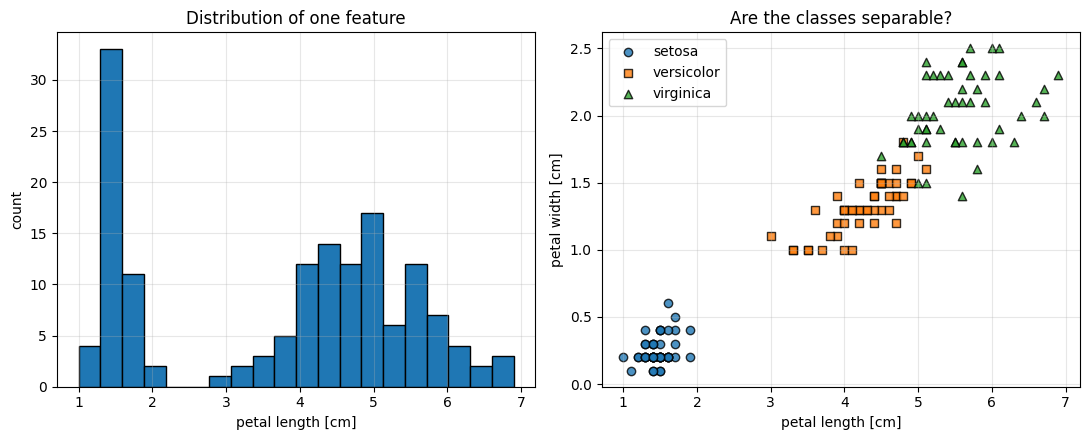

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].hist(X[:, 2], bins=20, edgecolor='black')
ax[0].set_xlabel('petal length [cm]')
ax[0].set_ylabel('count')
ax[0].set_title('Distribution of one feature')

for label, marker in zip(np.unique(y), ('o', 's', '^')):
    ax[1].scatter(X[y == label, 2], X[y == label, 3],
                  marker=marker, alpha=0.8, edgecolor='k',
                  label=data.target_names[label])
ax[1].set_xlabel('petal length [cm]')
ax[1].set_ylabel('petal width [cm]')
ax[1].set_title('Are the classes separable?')
ax[1].legend()

plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

print('train', X_train.shape, ' test', X_test.shape)
print()
print('train class proportions:', np.round(np.bincount(y_train) / len(y_train), 3))
print('test  class proportions:', np.round(np.bincount(y_test) / len(y_test), 3))

train (105, 4)  test (45, 4)

train class proportions: [0.333 0.333 0.333]
test  class proportions: [0.333 0.333 0.333]


In [16]:
n = len(y)
y_imb = (rng.random(n) < 0.05).astype(int)   # 1 with prob 0.05, else 0
print('overall imbalanced class counts:', np.bincount(y_imb))
print('overall imbalanced class proportions:', np.round(np.bincount(y_imb) / n, 3))
print()

# Split WITHOUT stratify
_, _, _, y_test_nostrat = train_test_split(
    X, y_imb, test_size=0.3, random_state=RANDOM_STATE)
print('WITHOUT stratify -> test set class counts:', np.bincount(y_test_nostrat))
print('WITHOUT stratify -> test set class proportions:', np.round(np.bincount(y_test_nostrat) / len(y_test_nostrat), 3))
print()

# Split WITH stratify
_, _, _, y_test_strat = train_test_split(
    X, y_imb, test_size=0.3, random_state=RANDOM_STATE, stratify=y_imb)
print('WITH stratify    -> test set class counts:', np.bincount(y_test_strat))
print('WITH stratify    -> test set class proportions:', np.round(np.bincount(y_test_strat) / len(y_test_strat), 3))
print()

print('What went wrong without stratify: the minority class (~5% of the data, only a handful of rows) '
      'gets split unevenly by chance, so the test set proportion drifts away from 5% (sometimes further, '
      'sometimes even to 0 samples of that class) -- stratify pins both splits to the original 95/5 ratio.')

overall imbalanced class counts: [145   5]
overall imbalanced class proportions: [0.967 0.033]

WITHOUT stratify -> test set class counts: [44  1]
WITHOUT stratify -> test set class proportions: [0.978 0.022]

WITH stratify    -> test set class counts: [43  2]
WITH stratify    -> test set class proportions: [0.956 0.044]

What went wrong without stratify: the minority class (~5% of the data, only a handful of rows) gets split unevenly by chance, so the test set proportion drifts away from 5% (sometimes further, sometimes even to 0 samples of that class) -- stratify pins both splits to the original 95/5 ratio.
